## TF-IDF
Método estadístico para medir la importancia de una palabra en un documento en relacion a una coleccion de textos. Más especificamente Frecuencia de términos o TF (Term Frequency) mide cuantas veces aparece una palabra en un documento, es decir qué tan importante es una palabra a un documento en relación a una colección de documentos. Y la Frecuencia inversa de documento o IDF (Inverse Document Frequency) reduce el peso de las palabras más comunes a través de multiples documentos a la vez que incrementa el peso de palabras raras. A este procedimiento se le conoce como "vectorizar"

Importamos la herramienta  `TfidfVectorizer` encargada del Procesamiento de Lenguaje Natural (NLP). Esta se encarga de convertir texto (las descripciones transacciones) en matrices numéricas ponderadas (el algoritmo matemático) entendible para los algoritmos de machine learning.  
Después importamos la funcion `train_test_split` que nos permitirá dividir la base de datos en dos partes: una para entrenar y otra para probar el entrenamiento.  
Finalmente la librería `pandas` que es un estándar para la manipulación de datos.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

Importamos datos y hacemos una revisión rápida.

In [14]:
df_gastos = pd.read_csv('../data/processed/df_gastos.csv')
df_gastos.head()

,descripcion_limpia,categorias
0,Doctor,Salud
1,Starbucks,Alimentacion
2,Cablebus,Transporte
3,Cafeteria local,Alimentacion
4,Trolebus,Transporte


### Vectorización y separación de variables
Tomamos la columna que contiene las transacciones `df_gastos['descripcion_limpia']` y lo asignamos a una variable, esta va a representar la informacíon que el modelo va a interpretar.  
De la misma forma tomamos `df_gastos['categorias']` y lo asignamos a una variable, esta va a ser el objetivo, es decir lo que el modelo va a predecir.  

In [15]:
X_texto = df_gastos['descripcion_limpia']
y_categoria = df_gastos['categorias']

Instanciamos la herramienta de Procesamiento de Lenguaje Natural (NLP).

In [16]:
vectorizador_tfidf = TfidfVectorizer()

El método `.fit` escanea las descripciones de los gastos y y constuye un vocabulario con ellas. Es decir se hace el TF-IDF posteriormente el el método `transform` aplica los patrones aprendidos utilizando ese vocabulario. El resultado es una matriz numérica donde cada fila es una transacción y cada columna es un número que representa la relevancia de una palabra, este resultado se guarda en `X_matriz_numerica`

In [17]:
X_matriz_numerica = vectorizador_tfidf.fit_transform(X_texto)

Definimos entrada y salida (x, y):  
- Tomamos la columna de las descripciones de las transacciones y las asignamos a la variable `x`.
- Tomamos la columna de las categorías y la asignamos a la variable `y`.

Parámetros de entrenamiento y prueba:
- Los datos son divididos en dos partes. Usaremos el estándar de `test_size=0.20`, que significa, 80% de los datos se usarán para que el modelo se entrene y el 20% restante para hacer una prueba final y medir su precisión.
- En `random_state=42` se guarda una semilla para garantizar la reproducibilidad en el equipo.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_matriz_numerica, y_categoria, test_size=0.20, random_state=42, stratify=y_categoria)

### Comprobación de resultados y resumen  
Comenzamos verificando las dimensiones con el método `shape`. El objetivo de los primeras cuatro líneas es revisar el tamaño geométrico. Primero `X_matriz_numerica.shape[0]` revisamos el numero de filas, que representan transacciones en esta caso, contando el 80% de la totalidad y el 20%.   
Por otro lado `X_matriz_numerica.shape[1]` nos muestra el número de columnas, que representan el número total de palabras únicas en todo el vocabulario.  Por ultimo al pedir `X_train.shape[0]` y `X_test.shape[0]` nos muestra la cantidad de datos usador tanto para entrenar como para evaluar respectivamente.   
Al llamar al método `.get_feature_names_out()` extraemos el vocabulario oficial construido por el vectorizador, y al guardarlo en una variable podemos acceder a los primeros 15 elementos de esa lista.

In [28]:
print(f"Total de transacciones: {X_matriz_numerica.shape[0]}")
print(f"Tamaño del vocabulario aprendido (Número de palabras únicas): {X_matriz_numerica.shape[1]}")
print(f"Datos para entrenar: {X_train.shape[0]}")
print(f"Datos para evaluar (prueba): {X_test.shape[0]}\n")

print("--- Un vistazo al vocabulario ---")
palabras_aprendidas = vectorizador_tfidf.get_feature_names_out()
print(palabras_aprendidas[:15])

Total de transacciones: 948
Tamaño del vocabulario aprendido (Número de palabras únicas): 116
Datos para entrenar: 758
Datos para evaluar (prueba): 190

--- Un vistazo al vocabulario ---
['agua' 'articulos' 'autobus' 'boleto' 'cable' 'cablebus' 'cafe'
 'cafeteria' 'caldera' 'camiseta' 'cartera' 'cena' 'ciclismo' 'cine'
 'ciudad']


## Aprendizaje automático y la evaluación de resultados
Importamos herramientas para implementar el algoritmo aprendizaje de tipo Random Forest, las métricas matemáticas para calificar su desempeño, y las librerías gráficas Matplotlib y Seaborn para visualizar los resultados

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Instanciamos el modelo y le damos la semilla `random_state=42` por motivos de reproducibilidad

In [29]:
modelo_rf = RandomForestClassifier(random_state=42)

Ejecutamos el método `.fit(X_train, y_train)`, el modelo analizará la matriz numérica de palabras junto con sus etiquetas correctas y aprenderá las reglas que definen a cada gasto.

In [30]:
modelo_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Con `.predict(X_test)` tomamos el 20% de datos de prueba y los usamos para que el modelo trate de separar la categoría de los datos y lo guardamos en una variable para poder visualizarlo posteriormente

In [31]:
predicciones = modelo_rf.predict(X_test)

### Metricas 
La Precisión General `accuracy_score(y_test, predicciones)` nos da un porcentaje rápido y directo de cuántas transacciones el modelo clasificó de forma correcta en total.

In [32]:
precision = accuracy_score(y_test, predicciones)
print(f"Precisión General (Accuracy): {precision * 100:.2f}%\n")

Precisión General (Accuracy): 97.89%



El Reporte de Clasificación es un desglose profundo que nos muestra el rendimiento del modelo categoría por categoría. Es ideal para auditar si el modelo identifica muy bien los gastos de "Transporte" pero es deficiente con los de "Regalos".

In [33]:
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

Alimentacion       0.98      1.00      0.99        62
   Educacion       1.00      0.50      0.67         2
        Ocio       0.84      1.00      0.91        16
       Salud       1.00      1.00      1.00         4
   Servicios       1.00      0.89      0.94         9
  Transporte       1.00      1.00      1.00        95
    Vivienda       0.00      0.00      0.00         2

    accuracy                           0.98       190
   macro avg       0.83      0.77      0.79       190
weighted avg       0.97      0.98      0.97       190



C:\Users\jesus\Desktop\hackathon_nlp\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jesus\Desktop\hackathon_nlp\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jesus\Desktop\hackathon_nlp\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

En la Matriz de Confusión usaremos Seaborn para dibujar un "mapa de calor" (heatmap). Esta gráfica cruza las categorías reales (lo que de verdad era el gasto) contra las predicciones (lo que el modelo creyó que era). Es la herramienta visual perfecta para detectar dónde están los puntos ciegos o las confusiones exactas del clasificador.

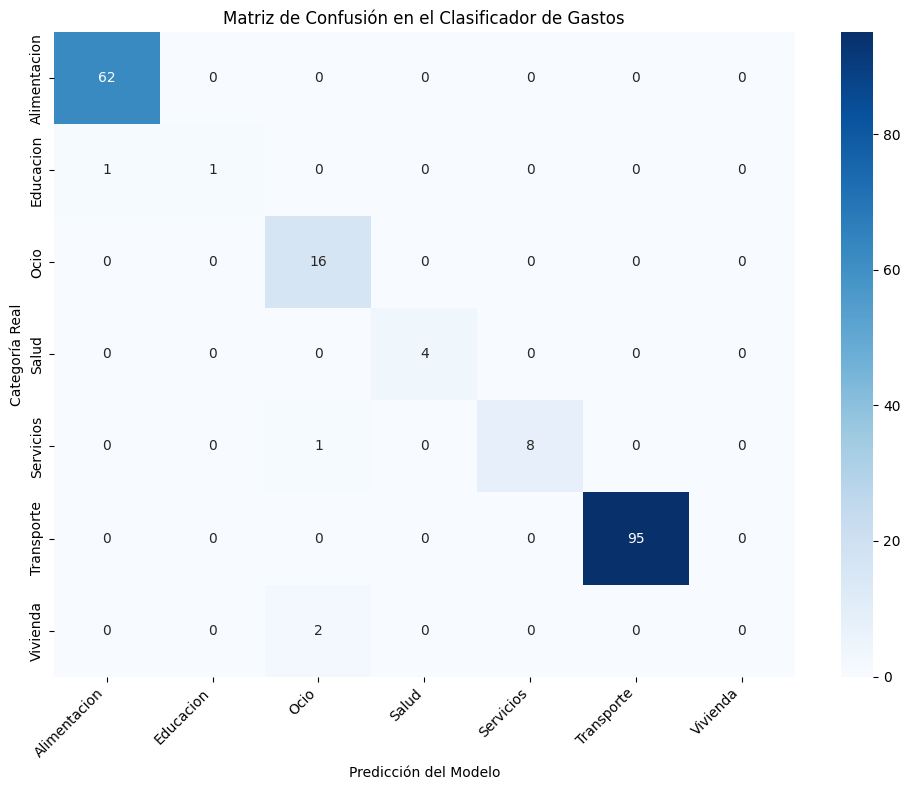

In [34]:
plt.figure(figsize=(10, 8))
matriz = confusion_matrix(y_test, predicciones)

etiquetas_unicas = sorted(y_test.unique()) 

sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=etiquetas_unicas, yticklabels=etiquetas_unicas)
plt.title('Matriz de Confusión en el Clasificador de Gastos')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Categoría Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Serialización del modelo
Importamos librería `joblib` que es usado para serializar modelos, aparentemente está más optimizada que `pickle` (una libreria análoga). Y también usaremos la libreria `os` para interactuar con el sistema operativo.

Guardamos el nombre de la carpeta en una variable y la usamos como parámetro al crear una carpeta en el entrono de trabajo con ese nombre, si la carpeta ya existe evitamos que lance un error con `exist_ok=True`. 

In [ ]:
#carpeta_modelos = 'artefactos_modelo'
#os.makedirs(carpeta_modelos, exist_ok=True)

Definimos las rutas de los archivos

In [ ]:
#ruta_modelo = f'{carpeta_modelos}/clasificador_gastos_rf.joblib'
#ruta_vectorizador = f'{carpeta_modelos}/vectorizador_tfidf.joblib'

Definimos las rutas de los archivos

In [ ]:
#ruta_modelo = f'{carpeta_modelos}/clasificador_gastos_rf.joblib'
#ruta_vectorizador = f'{carpeta_modelos}/vectorizador_tfidf.joblib'

Con el método `.dump()` serializamos (guardamos) ambos objetos en la carpeta antes creada como archivos .joblib. Es de vital importancia guardar ambos ya que modelo `modelo_rf` solo entiende números obligatoriamente se necesita el vectorizador `vectorizador_tfidf` entrenado para que actúe como traductor de las nuevas palabras al mismo idioma numérico que aprendió el modelo. 

In [ ]:
#joblib.dump(modelo_rf, ruta_modelo)
#joblib.dump(vectorizador_tfidf, ruta_vectorizador)

## Serializacion a `.pkl`
Por motivos de compatibilidad serializaremos mejor en archivo con extension pikle


In [35]:
import pickle

In [36]:
with open("../models/vectorizador_tfidf.pkl", "wb") as archivo:
    pickle.dump(vectorizador_tfidf, archivo)

In [37]:
with open("../models/clasificador_gastos_rf", "wb") as archivo:
    pickle.dump(modelo_rf, archivo)

## Simulación de entorno de producción
Este es el proceso de deserialización. Se esta simulando lo que hará la API cuando arranque: ir al disco duro, leer los archivos .joblib y almacenarlos en la memoria para usarlos.

In [ ]:
#  modelo_cargado = joblib.load(ruta_modelo)
#  vectorizador_cargado = joblib.load(ruta_vectorizador)

In [41]:
with open('../models/clasificador_gastos_rf', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)
with open('../models/vectorizador_tfidf.pkl', 'rb') as archivo:
    vectorizador_cargado = pickle.load(archivo)

print(modelo_cargado, vectorizador_cargado)

RandomForestClassifier(random_state=42) TfidfVectorizer()


Simulamos un texto que llega desde la API (JSON) escrito por un usuario real en la variable `texto_nuevo_api`.  
El metodo `.transform(texto_nuevo_api)` toma el texto entrante de la API ("Pagué el pasaje...") y lo mapea matemáticamente usando el vocabulario estático que aprendió durante la fase de entrenamiento.  
Finalmente el modelo ya cargado recibe la matriz numérica del paso anterior y escupe su predicción final. 
Al final imprimimos en pantalla el texto a evaluar seguido de la predicción hecha. 

In [48]:
texto_nuevo_api = ["Boleto de metrobus"]
texto_vectorizado = vectorizador_cargado.transform(texto_nuevo_api)
prediccion = modelo_cargado.predict(texto_vectorizado)

print(f"Texto entrante de la API: '{texto_nuevo_api[0]}'")
print(f"Predicción del modelo cargado: {prediccion[0]}")

Texto entrante de la API: 'Boleto de metrobus'
Predicción del modelo cargado: Transporte
